<a href="https://colab.research.google.com/github/andreanchalvari/SkripsiAndre/blob/main/64GAN_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Setup dan Import Library

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import glob
import rasterio
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')
from scipy.ndimage import binary_closing, binary_opening
import tifffile

# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Konfigurasi untuk menghemat RAM
tf.config.optimizer.set_jit(True)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# Batasi penggunaan GPU memory
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

# Fungsi untuk membersihkan memory
def clear_memory():
    gc.collect()
    tf.keras.backend.clear_session()

Mounted at /content/drive


# Section 2: Konfigurasi dan Path

In [ ]:
BASE_PATH = '/content/drive/MyDrive/landsat_dataset_new'

# Patch configuration
PATCH_SIZE = 64

# Training configuration
BATCH_SIZE = 16
EPOCHS = 5
BUFFER_SIZE = 50

# Data configuration
CHANNELS = 8

TRAIN_SPLIT = 0.7
TEST_SPLIT  = 0.3

# Cropping
# Dari 7771 x 7641 → 7744 x 7616
CROP_HEIGHT = 7744
CROP_WIDTH  = 7616

# PATH OUTPUT
MODEL_SAVE_PATH = '/content/drive/MyDrive/model_prediksi_awan_balance_64x64'
RESULTS_PATH = '/content/drive/MyDrive/hasil_prediksi_awan_balance_64x64'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# BAND CONFIGURATION
BAND_PATTERNS = {
    'B1': '*SR_B1.TIF',
    'B2': '*SR_B2.TIF',
    'B3': '*SR_B3.TIF',
    'B4': '*SR_B4.TIF',
    'B5': '*SR_B5.TIF',
    'B6': '*SR_B6.TIF',
    'B7': '*SR_B7.TIF',
    'B10': '*ST_B10.TIF',
    'QA': '*QA_PIXEL.TIF'
}

BAND_ORDER = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B10', 'QA']

VISUALISASI TIAP BAND

In [ ]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

SCENE_PATH = '/content/drive/MyDrive/landsat_dataset_new'
CROP_HEIGHT = 7744
CROP_WIDTH = 7616

BAND_PATTERNS = {
    'B1': '*SR_B1.TIF',
    'B2': '*SR_B2.TIF',
    'B3': '*SR_B3.TIF',
    'B4': '*SR_B4.TIF',
    'B5': '*SR_B5.TIF',
    'B6': '*SR_B6.TIF',
    'B7': '*SR_B7.TIF',
    'B10': '*ST_B10.TIF',
    'QA': '*QA_PIXEL.TIF'
}

BAND_ORDER = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B10', 'QA']

# LOAD & CROP BAND
bands = {}

print("=== INFORMASI UKURAN BAND ===")
for band_name in BAND_ORDER:
    pattern = BAND_PATTERNS[band_name]
    file_path = glob.glob(os.path.join(SCENE_PATH, pattern))[0]

    with rasterio.open(file_path) as src:
        band = src.read(1)
        original_shape = band.shape

        # Cropping
        band = band[:CROP_HEIGHT, :CROP_WIDTH]
        cropped_shape = band.shape

        bands[band_name] = band

        print(f"{band_name}")
        print(f"  Ukuran asli   : {original_shape[0]} x {original_shape[1]} pixel")
        print(f"  Ukuran crop   : {cropped_shape[0]} x {cropped_shape[1]} pixel")
        print(f"  Data type     : {band.dtype}")
        print("-" * 40)

# VISUALISASI BAND
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, band_name in enumerate(BAND_ORDER):
    band = bands[band_name]

    axes[idx].imshow(band, cmap='gray')
    axes[idx].set_title(f'Band {band_name}')
    axes[idx].axis('off')

plt.suptitle('Visualisasi Semua Band Landsat yang Digunakan', fontsize=16)
plt.tight_layout()
plt.show()

=== INFORMASI UKURAN BAND ===
B1
  Ukuran asli   : 7771 x 7641 pixel
  Ukuran crop   : 7744 x 7616 pixel
  Data type     : uint16
----------------------------------------
B2
  Ukuran asli   : 7771 x 7641 pixel
  Ukuran crop   : 7744 x 7616 pixel
  Data type     : uint16
----------------------------------------


KeyboardInterrupt: 

VISUASLISASI RGB

Band 2 : LC09_L2SP_106069_20251106_20251108_02_T1_SR_B2.TIF
Band 3 : LC09_L2SP_106069_20251106_20251108_02_T1_SR_B3.TIF
Band 4 : LC09_L2SP_106069_20251106_20251108_02_T1_SR_B4.TIF
Ukuran asli : (7771, 7641)
Ukuran setelah crop : (7744, 7616)


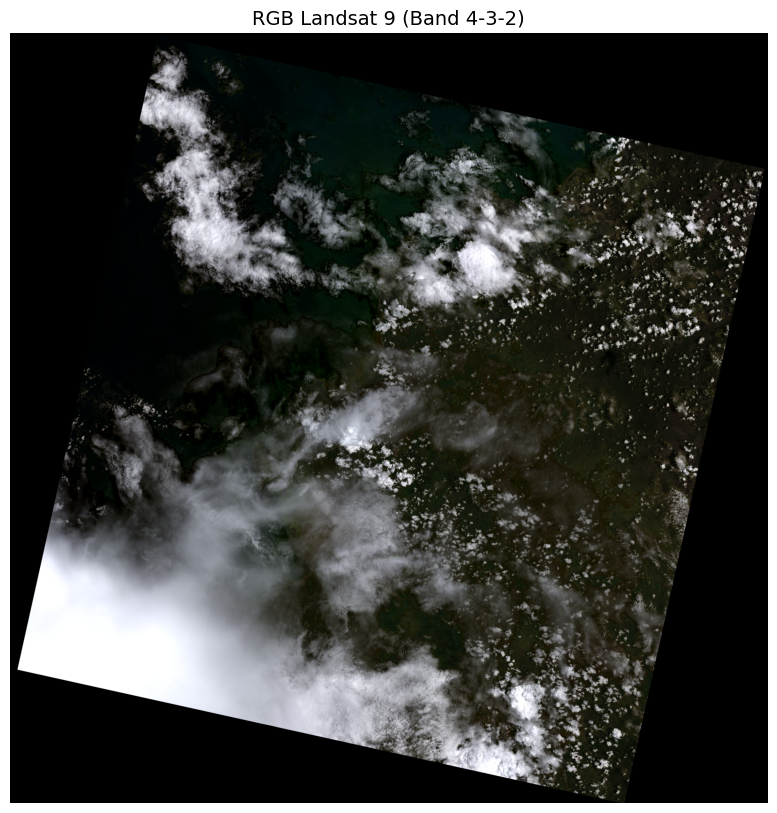

RGB berhasil disimpan di:
/content/drive/MyDrive/hasil_prediksi_awan_balance_64x64/RGB_Landsat9.png


In [ ]:
# VISUALISASI CITRA RGB LANDSAT 9 (B4-B3-B2)
import os
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Cari file band
b2_path = glob.glob(os.path.join(BASE_PATH, BAND_PATTERNS['B2']))[0]
b3_path = glob.glob(os.path.join(BASE_PATH, BAND_PATTERNS['B3']))[0]
b4_path = glob.glob(os.path.join(BASE_PATH, BAND_PATTERNS['B4']))[0]

print("Band 2 :", os.path.basename(b2_path))
print("Band 3 :", os.path.basename(b3_path))
print("Band 4 :", os.path.basename(b4_path))

# Baca raster
with rasterio.open(b2_path) as src:
    B2 = src.read(1)

with rasterio.open(b3_path) as src:
    B3 = src.read(1)

with rasterio.open(b4_path) as src:
    B4 = src.read(1)

print("Ukuran asli :", B2.shape)

# Crop sesuai penelitian
B2 = B2[:CROP_HEIGHT, :CROP_WIDTH]
B3 = B3[:CROP_HEIGHT, :CROP_WIDTH]
B4 = B4[:CROP_HEIGHT, :CROP_WIDTH]

print("Ukuran setelah crop :", B2.shape)

# Surface Reflectance Scaling
SCALE_FACTOR = 0.0000275
OFFSET = -0.2

B2 = B2.astype(np.float32) * SCALE_FACTOR + OFFSET
B3 = B3.astype(np.float32) * SCALE_FACTOR + OFFSET
B4 = B4.astype(np.float32) * SCALE_FACTOR + OFFSET

# Clip nilai reflektansi
B2 = np.clip(B2, 0, 1)
B3 = np.clip(B3, 0, 1)
B4 = np.clip(B4, 0, 1)

# Susun RGB
rgb = np.dstack((B4, B3, B2))

# Contrast Stretch (2%-98%)
p2 = np.percentile(rgb, 2)
p98 = np.percentile(rgb, 98)

rgb_stretch = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Visualisasi
plt.figure(figsize=(10,10))

plt.imshow(rgb_stretch)

plt.title("RGB Landsat 9 (Band 4-3-2)", fontsize=14)

plt.axis("off")

plt.show()

# Simpan gambar
output_rgb = os.path.join(RESULTS_PATH, "RGB_Landsat9.png")

plt.figure(figsize=(10,10), dpi=300)

plt.imshow(rgb_stretch)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    output_rgb,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

print("RGB berhasil disimpan di:")
print(output_rgb)

VISUALISASI GROUND TRUTH

In [ ]:
import os
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# MENCARI FILE QA_PIXEL
qa_pattern = os.path.join(BASE_PATH, "**", BAND_PATTERNS['QA'])
qa_files = glob.glob(qa_pattern, recursive=True)

if len(qa_files) == 0:
    raise FileNotFoundError("File QA_PIXEL tidak ditemukan!")

qa_path = qa_files[0]

print("QA_PIXEL ditemukan:")
print(qa_path)

# MEMBACA QA_PIXEL
with rasterio.open(qa_path) as src:
    qa = src.read(1)

print("\nUkuran raster asli :", qa.shape)

# Crop sesuai preprocessing
qa = qa[:CROP_HEIGHT, :CROP_WIDTH]

print("Ukuran setelah crop:", qa.shape)

# EKSTRAK BIT QA_PIXEL
qa = qa.astype(np.uint16)

# Bit 1 = Dilated Cloud
dilated_cloud = ((qa >> 1) & 1)

# Bit 3 = Cloud
cloud = ((qa >> 3) & 1)

# GROUND TRUTH (Cloud = Dilated Cloud OR Cloud)
ground_truth = np.where(
    (dilated_cloud == 1) | (cloud == 1),
    1,
    0
).astype(np.uint8)

# STATISTIK
total_pixel = ground_truth.size
cloud_pixel = np.sum(ground_truth)
noncloud_pixel = total_pixel - cloud_pixel

print("\n========== GROUND TRUTH ==========")
print(f"Total Pixel      : {total_pixel:,}")
print(f"Cloud Pixel      : {cloud_pixel:,}")
print(f"Non-Cloud Pixel  : {noncloud_pixel:,}")
print(f"Cloud (%)        : {cloud_pixel/total_pixel*100:.2f}%")
print(f"Non-Cloud (%)    : {noncloud_pixel/total_pixel*100:.2f}%")

# VISUALISASI
plt.figure(figsize=(10,10))

plt.imshow(ground_truth, cmap='gray')

plt.title("Ground Truth Cloud Mask (Bit 1 + Bit 3)", fontsize=14)

plt.axis("off")

plt.show()

QA_PIXEL ditemukan:
/content/drive/MyDrive/landsat_dataset_new/LC09_L2SP_106069_20251106_20251108_02_T1_QA_PIXEL.TIF

Ukuran raster asli : (7771, 7641)
Ukuran setelah crop: (7744, 7616)

========== GROUND TRUTH ==========
Total Pixel      : 58,978,304
Cloud Pixel      : 33,596,828
Non-Cloud Pixel  : 25,381,476
Cloud (%)        : 56.96%
Non-Cloud (%)    : 43.04%


# Section 3: Data Preprocessing dan Patch Creation

In [ ]:
import os
import glob
import numpy as np
import rasterio
import gc

# Data Preprocessor
class LandsatDataProcessor:
    def __init__(self, patch_size=64, crop_height=7744, crop_width=7616):
        self.patch_size = patch_size
        self.crop_height = crop_height
        self.crop_width = crop_width

    def load_all_bands(self, scene_folder):
        """Load semua band untuk satu scene"""
        bands_data = {}

        for band_name, pattern in BAND_PATTERNS.items():
            file_path = glob.glob(os.path.join(scene_folder, pattern))
            if not file_path:
                print(f"Band {band_name} tidak ditemukan")
                return None

            with rasterio.open(file_path[0]) as src:
                band = src.read(1).astype(np.float32)

                # Cropping
                band = band[:self.crop_height, :self.crop_width]
                bands_data[band_name] = band

        return bands_data

    def extract_cloud_mask_from_qa(self, qa_band):

        qa_int = qa_band.astype(np.uint16)

        # Bit 1 = Dilated Cloud
        dilated_cloud_bits = (qa_int >> 1) & 1

        # Bit 3 = High Confidence Cloud
        cloud_bits = (qa_int >> 3) & 1

        # Ground Truth: Dilated Cloud atau High Confidence Cloud
        cloud_mask = np.where(
            (dilated_cloud_bits == 1) | (cloud_bits == 1),
            1.0,
            0.0
        ).astype(np.float32)

        return cloud_mask

    def preprocess_bands(self, bands_data):
        """Preprocess semua band dan stack"""
        processed_bands = []

        # SR Bands B1-B7
        for band_name in ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7']:
            band = bands_data[band_name]

            # Scalling SR
            scaled = band * 0.0000275 - 0.2
            clipped = np.clip(scaled, 0, 1)

            p1, p99 = np.percentile(clipped, 1), np.percentile(clipped, 99)

            # Normalisasi
            normalized = (clipped - p1) / (p99 - p1 + 1e-7)

            processed_bands.append(normalized)

        # Thermal Band B10
        b10 = bands_data['B10']

        # Scalling B10
        scaled_b10 = b10 * 0.00341802 + 149.0

        # Normalized B10
        normalized_b10 = (scaled_b10 - 200) / 150
        normalized_b10 = np.clip(normalized_b10, 0, 1)
        processed_bands.append(normalized_b10)

        # Stack → (H, W, 8)
        stacked_image = np.stack(processed_bands, axis=-1)

        return stacked_image

    def create_all_patches(self, image, mask):
        h, w, c = image.shape
        ps = self.patch_size

        patches = []
        mask_patches = []

        for y in range(0, h, ps):
            for x in range(0, w, ps):
                patch = image[y:y+ps, x:x+ps, :]
                mask_patch = mask[y:y+ps, x:x+ps]

                patches.append(patch)
                mask_patches.append(mask_patch)

        return np.array(patches), np.array(mask_patches)

# Dataset Creation
def create_dataset(base_path, max_scenes=1):
    processor = LandsatDataProcessor(PATCH_SIZE, CROP_HEIGHT, CROP_WIDTH)

    all_images = []
    all_masks = []

    # Cari scene
    scenes = []
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            tif_files = [f for f in os.listdir(item_path) if f.endswith('.TIF')]
            if len(tif_files) >= 9:
                scenes.append(item_path)

    # Fallback jika tidak ada subfolder
    if not scenes:
        tif_files = [f for f in os.listdir(base_path) if f.endswith('.TIF')]
        if len(tif_files) >= 9:
            scenes = [base_path]

    scenes = scenes[:max_scenes]
    print(f"Found {len(scenes)} scene(s)")

    for scene_path in scenes:
        print(f"\nProcessing scene: {os.path.basename(scene_path)}")

        bands_data = processor.load_all_bands(scene_path)
        if bands_data is None:
            continue

        image = processor.preprocess_bands(bands_data)
        cloud_mask = processor.extract_cloud_mask_from_qa(bands_data['QA'])

        image_patches, mask_patches = processor.create_all_patches(image, cloud_mask)

        all_images.append(image_patches)
        all_masks.append(mask_patches)

        print(f"  Total patches from scene: {len(image_patches)}")

        del bands_data, image, cloud_mask
        gc.collect()

    if not all_images:
        return None, None

    all_images = np.vstack(all_images)
    all_masks = np.vstack(all_masks)
    all_masks = np.expand_dims(all_masks, axis=-1)

    print("\n=== FINAL DATASET ===")
    print(f"Total patches: {len(all_images)}")
    print(f"Image shape : {all_images[0].shape}")
    print(f"Mask shape  : {all_masks[0].shape}")
    print(f"Images size: {all_images.nbytes / 1024**2:.2f} MB")
    print(f"Masks size : {all_masks.nbytes / 1024**2:.2f} MB")

    return all_images, all_masks

# RUN
print("Loading full patch dataset...")
images, masks = create_dataset(BASE_PATH, max_scenes=1)

Loading full patch dataset...
Found 1 scene(s)

Processing scene: landsat_dataset_new
  Total patches from scene: 14399

=== FINAL DATASET ===
Total patches: 14399
Image shape : (64, 64, 8)
Mask shape  : (64, 64, 1)
Images size: 1799.88 MB
Masks size : 224.98 MB


# Section 4: Split Dataset

PIXEL BALANCE DALAM PATCH

In [ ]:
import numpy as np
from tqdm import tqdm

print("=== PIXEL BALANCING DALAM PATCH ===")

balanced_X = []
balanced_y = []

total_cloud = 0
total_non = 0

for idx in tqdm(range(len(images))):

    img_patch = images[idx]
    mask_patch = masks[idx].squeeze()

    cloud_idx = np.argwhere(mask_patch == 1)
    non_idx   = np.argwhere(mask_patch == 0)

    n_cloud = len(cloud_idx)
    n_non   = len(non_idx)

    if n_cloud == 0 or n_non == 0:
        continue

    n_take = min(n_cloud, n_non)

    cloud_sel = cloud_idx[np.random.choice(n_cloud, n_take, replace=False)]
    non_sel   = non_idx[np.random.choice(n_non, n_take, replace=False)]

    # ambil pixel band
    for c in cloud_sel:
        balanced_X.append(img_patch[c[0], c[1], :])
        balanced_y.append(1)
    for n in non_sel:
        balanced_X.append(img_patch[n[0], n[1], :])
        balanced_y.append(0)

    total_cloud += n_take
    total_non += n_take

balanced_X = np.array(balanced_X, dtype=np.float32)
balanced_y = np.array(balanced_y, dtype=np.float32)

print("\n=== HASIL BALANCED DATASET ===")
print("Cloud pixel   :", total_cloud)
print("Non-cloud pixel:", total_non)
print("Total pixel   :", len(balanced_X))
print("Shape X:", balanced_X.shape)
print("Shape y:", balanced_y.shape)

=== PIXEL BALANCING DALAM PATCH ===


100%|██████████| 14399/14399 [00:03<00:00, 4126.31it/s]



=== HASIL BALANCED DATASET ===
Cloud pixel   : 2088852
Non-cloud pixel: 2088852
Total pixel   : 4177704
Shape X: (4177704, 8)
Shape y: (4177704,)


SPLIT DATASET

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

print("Shape X:", balanced_X.shape)
print("Shape y:", balanced_y.shape)

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    balanced_X,
    balanced_y,
    test_size=0.3,        # 30% testing
    train_size=0.7,       # 70% training
    stratify=balanced_y,
    random_state=42
)

# Verifikasi Distribusi
def print_distribution(name, y):
    total = len(y)
    cloud = np.sum(y == 1)
    noncloud = np.sum(y == 0)
    print(f"{name}")
    print(f"  Total     : {total:,}")
    print(f"  Cloud     : {cloud:,} ({cloud/total*100:.2f}%)")
    print(f"  Non-cloud : {noncloud:,} ({noncloud/total*100:.2f}%)")

print("\n=== DISTRIBUSI DATASET ===")
print_distribution("TRAINING SET", y_train)
print_distribution("TESTING SET", y_test)

Shape X: (4177704, 8)
Shape y: (4177704,)

=== DISTRIBUSI DATASET ===
TRAINING SET
  Total     : 2,924,392
  Cloud     : 1,462,196 (50.00%)
  Non-cloud : 1,462,196 (50.00%)
TESTING SET
  Total     : 1,253,312
  Cloud     : 626,656 (50.00%)
  Non-cloud : 626,656 (50.00%)


# Section 5: Arsitektur Generator dan Diskriminator

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_generator(input_dim=8):

    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name="Generator_PixelGAN")

In [ ]:
def build_discriminator(input_dim=8):

    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name="Discriminator_PixelGAN")

In [ ]:
generator = build_generator(8)
discriminator = build_discriminator(9)

bce = tf.keras.losses.BinaryCrossentropy()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

#Section 6: Training

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_X,
    balanced_y,
    test_size=0.3,
    stratify=balanced_y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (2924392, 8)
Test shape : (1253312, 8)


In [ ]:
@tf.function
def train_step(real_pixels, real_labels):

    real_labels = tf.expand_dims(real_labels, axis=1)

    # Train Discriminator
    with tf.GradientTape() as disc_tape:

        fake_labels = generator(real_pixels, training=True)

        real_input = tf.concat([real_pixels, real_labels], axis=1)
        fake_input = tf.concat([real_pixels, fake_labels], axis=1)

        real_output = discriminator(real_input, training=True)
        fake_output = discriminator(fake_input, training=True)

        disc_loss = (
            bce(tf.ones_like(real_output), real_output)
            +
            bce(tf.zeros_like(fake_output), fake_output)
        )

    gradients_disc = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    disc_optimizer.apply_gradients(
        zip(gradients_disc, discriminator.trainable_variables)
    )

    # Train Generator
    with tf.GradientTape() as gen_tape:

        fake_labels = generator(real_pixels, training=True)

        fake_input = tf.concat([real_pixels, fake_labels], axis=1)
        fake_output = discriminator(fake_input, training=True)

        # Adversarial Loss
        adv_loss = bce(
            tf.ones_like(fake_output),
            fake_output
        )

        # Reconstruction Loss
        recon_loss = bce(
            real_labels,
            fake_labels
        )

        gen_loss = recon_loss + 0.1 * adv_loss

    gradients_gen = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gen_optimizer.apply_gradients(
        zip(gradients_gen, generator.trainable_variables)
    )

    return gen_loss, disc_loss, recon_loss, adv_loss

In [ ]:
BATCH_SIZE = 2048

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
g_history = []
d_history = []
recon_history = []
adv_history = []

In [ ]:
import os

EPOCHS = 5

for epoch in range(EPOCHS):

    g_loss_epoch = 0
    d_loss_epoch = 0
    recon_epoch = 0
    adv_epoch = 0

    steps = 0

    for pixels_batch, labels_batch in train_dataset:

        g_loss, d_loss, recon_loss, adv_loss = train_step(
            pixels_batch,
            labels_batch
        )

        g_loss_epoch += g_loss
        d_loss_epoch += d_loss
        recon_epoch += recon_loss
        adv_epoch += adv_loss

        steps += 1

    # Rata-rata loss tiap epoch
    mean_g = float(g_loss_epoch / steps)
    mean_d = float(d_loss_epoch / steps)
    mean_recon = float(recon_epoch / steps)
    mean_adv = float(adv_epoch / steps)

    g_history.append(mean_g)
    d_history.append(mean_d)
    recon_history.append(mean_recon)
    adv_history.append(mean_adv)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Generator Loss     :", mean_g)
    print("Discriminator Loss :", mean_d)
    print("Reconstruction Loss:", mean_recon)
    print("Adversarial Loss   :", mean_adv)

# Simpan model
generator.save_weights(
    os.path.join(
        MODEL_SAVE_PATH,
        "generator_final.weights.h5"
    )
)

discriminator.save_weights(
    os.path.join(
        MODEL_SAVE_PATH,
        "discriminator_final.weights.h5"
    )
)

print("\n======================================")
print("Training selesai.")
print("Model hasil epoch terakhir berhasil disimpan.")
print("Generator :", os.path.join(MODEL_SAVE_PATH, "generator_final.weights.h5"))
print("Discriminator :", os.path.join(MODEL_SAVE_PATH, "discriminator_final.weights.h5"))
print("======================================")


Epoch 1/5
Generator Loss     : 0.41125401854515076
Discriminator Loss : 1.1269170045852661
Reconstruction Loss: 0.2944006025791168
Adversarial Loss   : 1.1685348749160767

Epoch 2/5
Generator Loss     : 0.5427635312080383
Discriminator Loss : 1.0259357690811157
Reconstruction Loss: 0.32468539476394653
Adversarial Loss   : 2.1807785034179688

Epoch 3/5
Generator Loss     : 0.6361175179481506
Discriminator Loss : 1.0379948616027832
Reconstruction Loss: 0.37643057107925415
Adversarial Loss   : 2.596874713897705

Epoch 4/5
Generator Loss     : 0.6982632279396057
Discriminator Loss : 1.0445163249969482
Reconstruction Loss: 0.41823235154151917
Adversarial Loss   : 2.8003151416778564

Epoch 5/5
Generator Loss     : 0.7457958459854126
Discriminator Loss : 1.045409917831421
Reconstruction Loss: 0.45316624641418457
Adversarial Loss   : 2.9263012409210205

Training selesai.
Model hasil epoch terakhir berhasil disimpan.
Generator : /content/drive/MyDrive/model_prediksi_awan_balance_64x64/generato

KURVA GENERATOR LOSS DAN DISCRIMINATOR LOSS

In [ ]:
import pandas as pd

# TABEL LOSS
loss_df = pd.DataFrame({
    "Epoch": np.arange(1, EPOCHS + 1),
    "Generator Loss": np.round(g_history, 6),
    "Discriminator Loss": np.round(d_history, 6)
})

print(loss_df)

# Simpan ke CSV
loss_df.to_csv(
    os.path.join(RESULTS_PATH, "generator_discriminator_loss.csv"),
    index=False
)

print("\nTabel loss berhasil disimpan.")

   Epoch  Generator Loss  Discriminator Loss
0      1        0.411254            1.126917
1      2        0.542764            1.025936
2      3        0.636118            1.037995
3      4        0.698263            1.044516
4      5        0.745796            1.045410

Tabel loss berhasil disimpan.


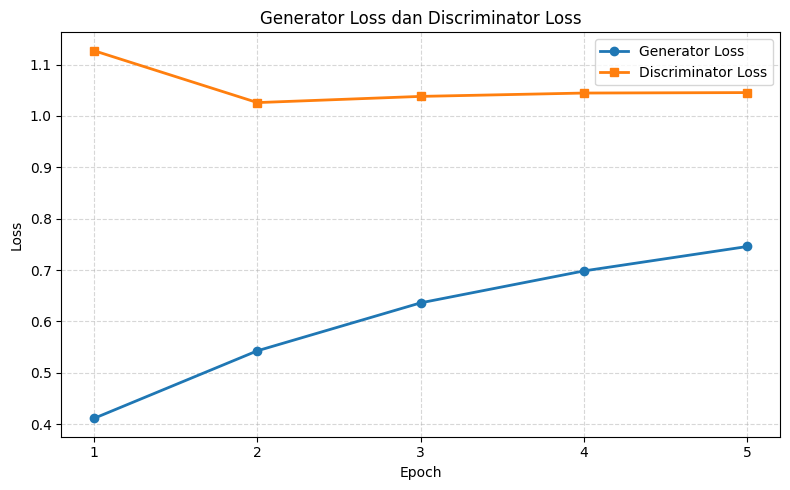


Kurva berhasil disimpan.


In [ ]:
import matplotlib.pyplot as plt

# KURVA LOSS
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS+1),
    g_history,
    marker='o',
    linewidth=2,
    label='Generator Loss'
)

plt.plot(
    range(1, EPOCHS+1),
    d_history,
    marker='s',
    linewidth=2,
    label='Discriminator Loss'
)

plt.title("Generator Loss dan Discriminator Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(range(1, EPOCHS+1))

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_PATH,
        "generator_discriminator_loss.png"
    ),
    dpi=300
)

plt.show()

print("\nKurva berhasil disimpan.")

KURVA RECONSTRUCTION DAN ADVERSARIAL LOSS

In [ ]:
import pandas as pd
import numpy as np
import os

# TABEL RECONSTRUCTION & ADVERSARIAL LOSS
loss_component_df = pd.DataFrame({
    "Epoch": np.arange(1, EPOCHS + 1),
    "Reconstruction Loss": np.round(recon_history, 6),
    "Adversarial Loss": np.round(adv_history, 6)
})

print(loss_component_df)

# Simpan ke CSV
loss_component_df.to_csv(
    os.path.join(
        RESULTS_PATH,
        "reconstruction_adversarial_loss.csv"
    ),
    index=False
)

print("\nTabel Reconstruction dan Adversarial Loss berhasil disimpan.")

   Epoch  Reconstruction Loss  Adversarial Loss
0      1             0.294401          1.168535
1      2             0.324685          2.180779
2      3             0.376431          2.596875
3      4             0.418232          2.800315
4      5             0.453166          2.926301

Tabel Reconstruction dan Adversarial Loss berhasil disimpan.


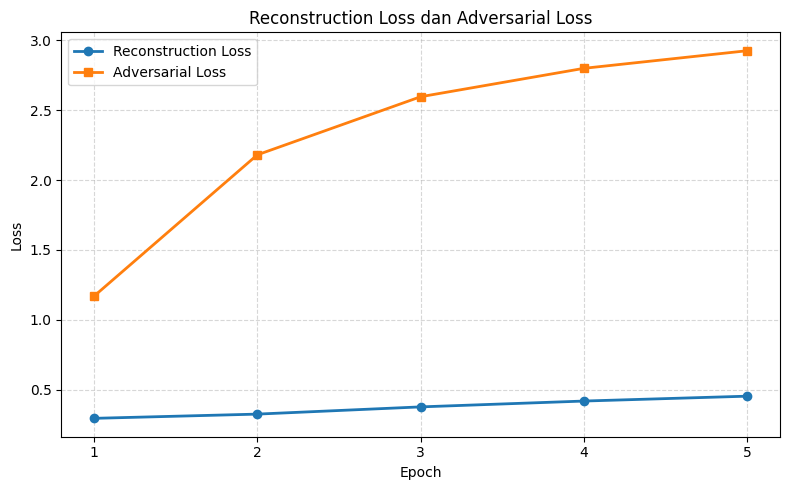


Kurva berhasil disimpan.


In [ ]:
import matplotlib.pyplot as plt

# KURVA RECONSTRUCTION & ADVERSARIAL LOSS
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS+1),
    recon_history,
    marker='o',
    linewidth=2,
    label='Reconstruction Loss'
)

plt.plot(
    range(1, EPOCHS+1),
    adv_history,
    marker='s',
    linewidth=2,
    label='Adversarial Loss'
)

plt.title("Reconstruction Loss dan Adversarial Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(range(1, EPOCHS+1))

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_PATH,
        "reconstruction_adversarial_loss.png"
    ),
    dpi=300
)

plt.show()

print("\nKurva berhasil disimpan.")

# Section 7: Testing

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("\n=== TESTING MODEL ===")

# Prediksi probabilitas
pred_probs = generator.predict(X_test, batch_size=4096, verbose=0)

# Threshold 0.5
pred_binary = (pred_probs > 0.5).astype(np.uint8).reshape(-1)
y_true = y_test.astype(np.uint8).reshape(-1)

print("Total test samples:", len(y_true))


=== TESTING MODEL ===
Total test samples: 1253312


LOAD GENERATOR FINAL

In [ ]:
import os
import tensorflow as tf

# Load bobot generator hasil epoch terakhir
generator.load_weights(
    os.path.join(
        MODEL_SAVE_PATH,
        "generator_final.weights.h5"
    )
)

print("Generator final berhasil dimuat.")

Generator final berhasil dimuat.


TESTING

In [ ]:
import numpy as np

print("Jumlah data testing :", len(X_test))

# Prediksi probabilitas
y_pred_prob = generator.predict(
    X_test,
    batch_size=32,
    verbose=1
)

# Threshold menjadi label biner
y_pred = (y_pred_prob >= 0.5).astype(np.uint8)

# Flatten seluruh pixel
y_true = y_test.flatten().astype(np.uint8)
y_pred = y_pred.flatten().astype(np.uint8)

print("Jumlah Ground Truth :", len(y_true))
print("Jumlah Prediksi     :", len(y_pred))

Jumlah data testing : 1253312
39166/39166 ━━━━━━━━━━━━━━━━━━━━ 35s 894us/step
Jumlah Ground Truth : 1253312
Jumlah Prediksi     : 1253312


CONFUSION MATRIX

Generator final berhasil dimuat.
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

========== CONFUSION MATRIX ==========
[[566103  60553]
 [ 76498 550158]]

True Negative (TN) : 566,103
False Positive (FP): 60,553
False Negative (FN): 76,498
True Positive (TP) : 550,158


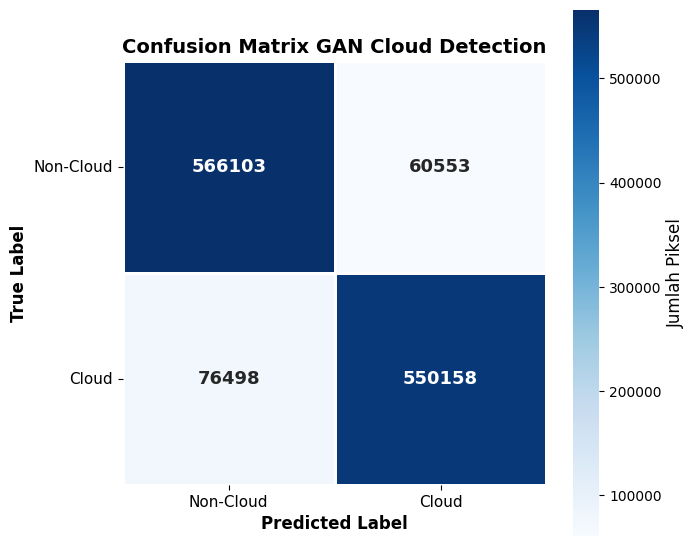


Confusion Matrix berhasil disimpan pada:
/content/drive/MyDrive/hasil_prediksi_awan_balance_64x64/gan_confusion_matrix.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# LOAD MODEL
generator.load_weights(
    os.path.join(
        MODEL_SAVE_PATH,
        "generator_final.weights.h5"
    )
)

print("Generator final berhasil dimuat.")

# PREDIKSI DATA TESTING
pred_probs = generator.predict(
    X_test,
    batch_size=4096,
    verbose=1
)

# Konversi probabilitas menjadi label biner
pred_binary = (pred_probs >= 0.5).astype(np.uint8).reshape(-1)

# Ground Truth
y_true = y_test.astype(np.uint8).reshape(-1)

# HITUNG CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    pred_binary
)

TN, FP, FN, TP = cm.ravel()

print("\n========== CONFUSION MATRIX ==========")
print(cm)

print(f"\nTrue Negative (TN) : {TN:,}")
print(f"False Positive (FP): {FP:,}")
print(f"False Negative (FN): {FN:,}")
print(f"True Positive (TP) : {TP:,}")

# VISUALISASI CONFUSION MATRIX
plt.figure(figsize=(7,6))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    square=True,
    cbar=True,
    xticklabels=["Non-Cloud", "Cloud"],
    yticklabels=["Non-Cloud", "Cloud"],
    annot_kws={
        "fontsize":13,
        "fontweight":"bold"
    }
)

# Keterangan warna (Color Bar)
cbar = ax.collections[0].colorbar
cbar.set_label(
    "Jumlah Piksel",
    fontsize=12
)

# Label Sumbu
plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Confusion Matrix GAN Cloud Detection",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

# SIMPAN GAMBAR
plt.savefig(
    os.path.join(
        RESULTS_PATH,
        "gan_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion Matrix berhasil disimpan pada:")
print(
    os.path.join(
        RESULTS_PATH,
        "gan_confusion_matrix.png"
    )
)

METRIK EVALUASI

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("\n===== METRIK EVALUASI =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


===== METRIK EVALUASI =====
Accuracy  : 0.8906
Precision : 0.9008
Recall    : 0.8779
F1 Score  : 0.8892


# Section 8: Visualisasi Cloud Prediction Mask

Generator final berhasil dimuat.

Load stacked image full scene...
Ukuran citra : (7744, 7616, 8)

Melakukan prediksi cloud mask...
Prediksi selesai.
Ukuran mask : (7744, 7616)

========== HASIL DETEKSI GAN ==========
Total Pixel      : 58,978,304
Cloud Pixel      : 33,502,891
Non-Cloud Pixel  : 25,475,413
Persentase Cloud : 56.81%
Persentase Non-Cloud : 43.19%


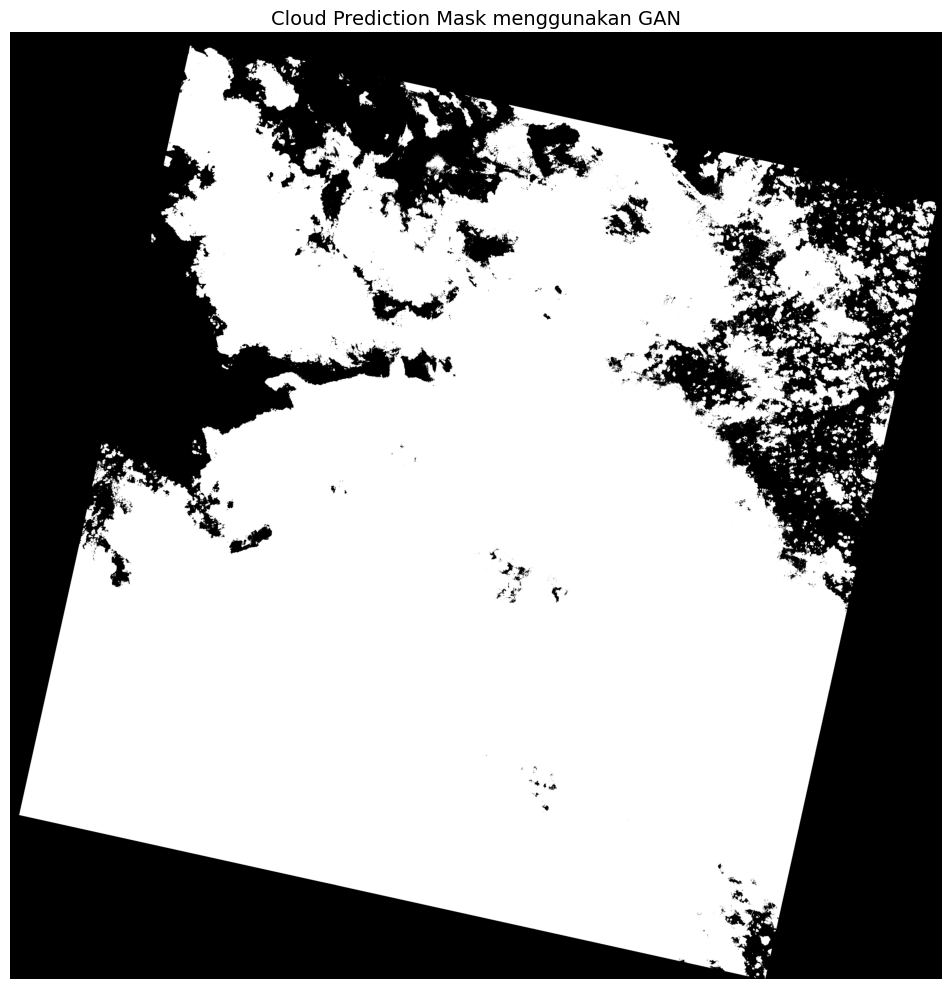


Cloud Prediction Mask berhasil disimpan.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# LOAD MODEL HASIL EPOCH TERAKHIR
generator.load_weights(
    os.path.join(
        MODEL_SAVE_PATH,
        "generator_final.weights.h5"
    )
)

print("Generator final berhasil dimuat.")

# LOAD FULL SCENE
print("\nLoad stacked image full scene...")

processor = LandsatDataProcessor(
    PATCH_SIZE,
    CROP_HEIGHT,
    CROP_WIDTH
)

scene_folders = []

for item in os.listdir(BASE_PATH):

    p = os.path.join(BASE_PATH, item)

    if os.path.isdir(p):
        scene_folders.append(p)

if len(scene_folders) == 0:
    scene_folders = [BASE_PATH]

scene_path = scene_folders[0]

bands_data = processor.load_all_bands(scene_path)
stacked_image = processor.preprocess_bands(bands_data)

H, W, C = stacked_image.shape

print("Ukuran citra :", stacked_image.shape)

# PREDIKSI CLOUD MASK
print("\nMelakukan prediksi cloud mask...")

pred_mask = np.zeros((H, W), dtype=np.uint8)

CHUNK_SIZE = 512

for y in range(0, H, CHUNK_SIZE):

    for x in range(0, W, CHUNK_SIZE):

        patch = stacked_image[
            y:y+CHUNK_SIZE,
            x:x+CHUNK_SIZE,
            :
        ]

        h, w, _ = patch.shape

        pixels = patch.reshape(-1, C)

        prediction = generator.predict(
            pixels,
            batch_size=4096,
            verbose=0
        )

        prediction = (prediction >= 0.5).astype(np.uint8)

        pred_mask[
            y:y+h,
            x:x+w
        ] = prediction.reshape(h, w)

print("Prediksi selesai.")

print("Ukuran mask :", pred_mask.shape)

# STATISTIK HASIL DETEKSI
cloud_pixel = np.sum(pred_mask == 1)

noncloud_pixel = np.sum(pred_mask == 0)

total_pixel = pred_mask.size

print("\n========== HASIL DETEKSI GAN ==========")

print(f"Total Pixel      : {total_pixel:,}")

print(f"Cloud Pixel      : {cloud_pixel:,}")

print(f"Non-Cloud Pixel  : {noncloud_pixel:,}")

print(f"Persentase Cloud : {cloud_pixel/total_pixel*100:.2f}%")

print(f"Persentase Non-Cloud : {noncloud_pixel/total_pixel*100:.2f}%")

# VISUALISASI CLOUD PREDICTION MASK
plt.figure(figsize=(10,10))

img = plt.imshow(
    pred_mask,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Cloud Prediction Mask menggunakan GAN",
    fontsize=14,
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_PATH,
        "cloud_prediction_mask.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nCloud Prediction Mask berhasil disimpan.")

In [ ]:
import os
import numpy as np

mask_path = os.path.join(
    RESULTS_PATH,
    "gan_mask64.npy"
)

np.save(mask_path, pred_mask)

print("\nGAN mask berhasil disimpan.")
print(f"Lokasi file : {mask_path}")


GAN mask berhasil disimpan.
Lokasi file : /content/drive/MyDrive/hasil_prediksi_awan_balance_64x64/gan_mask64.npy


OVERLAY GROUND TRUTH DAN MASK GAN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

# PASTIKAN UKURAN SAMA
assert ground_truth.shape == pred_mask.shape, \
    "Ukuran Ground Truth dan Prediction harus sama."

# MEMBUAT OVERLAY
overlay = np.zeros((ground_truth.shape[0],
                    ground_truth.shape[1],
                    3),
                   dtype=np.uint8)

# Non-Cloud benar -> Hitam
overlay[(ground_truth == 0) & (pred_mask == 0)] = [0, 0, 0]

# Cloud benar -> Hijau
overlay[(ground_truth == 1) & (pred_mask == 1)] = [0, 255, 0]

# Salah deteksi cloud -> Merah
overlay[(ground_truth == 0) & (pred_mask == 1)] = [255, 0, 0]

# Cloud tidak terdeteksi -> Kuning
overlay[(ground_truth == 1) & (pred_mask == 0)] = [255, 255, 0]

# HITUNG JUMLAH MASING-MASING KATEGORI
correct_cloud = np.sum((ground_truth == 1) & (pred_mask == 1))
correct_noncloud = np.sum((ground_truth == 0) & (pred_mask == 0))
false_alarm = np.sum((ground_truth == 0) & (pred_mask == 1))
missed_cloud = np.sum((ground_truth == 1) & (pred_mask == 0))

print("\n========== PERBANDINGAN GROUND TRUTH DAN HASIL PREDIKSI ==========")
print(f"Area Cloud yang Berhasil Dideteksi           : {correct_cloud:,}")
print(f"Area Non-Cloud yang Berhasil Diidentifikasi  : {correct_noncloud:,}")
print(f"Area Non-Cloud yang Salah Terdeteksi Cloud   : {false_alarm:,}")
print(f"Area Cloud yang Gagal Dideteksi              : {missed_cloud:,}")

# VISUALISASI
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='black',
          edgecolor='black',
          label='Area Non-Cloud'),

    Patch(facecolor='green',
          edgecolor='black',
          label='Area Cloud yang Berhasil Dideteksi'),

    Patch(facecolor='red',
          edgecolor='black',
          label='Area Non-Cloud yang Salah Terdeteksi sebagai Cloud'),

    Patch(facecolor='yellow',
          edgecolor='black',
          label='Area Cloud yang Gagal Dideteksi')
]

plt.figure(figsize=(10,10))

plt.imshow(overlay)

plt.title(
    "Overlay Ground Truth dan Prediksi GAN",
    fontsize=14,
)

plt.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_PATH,
        "gan_overlay_prediction.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nOverlay berhasil disimpan di:")
print(os.path.join(RESULTS_PATH, "gan_overlay_prediction.png"))

NameError: name 'ground_truth' is not defined